# Crime Trend Analysis

This notebook analyses the final reporting dataset to answer the following business questions:

1. How is overall crime changing over time for each police force?
2. What crime types drive crime volume, and how does the mix change over time?
3. Are there seasonal patterns or anomalous spikes at force or category level?
4. How do selected police forces compare head-to-head on key metrics?
5. How do forces compare on normalised crime rates (e.g. per 1,000 residents)?
6. How does crime data relate to population and socioeconomic context?
7. Do any areas show repeat seasonal patterns?
8. Are there geographic clusters (hotspots) of specific crime categories, and how do these clusters differ by police force? (optional)

The analysis uses the final Gold/reporting dataset exported from Snowflake.

## Import + Read file

In [26]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
crime = pd.read_csv("crime_reporting_powerbi_final.csv")

In [4]:
print("Rows:", len(crime))
crime.head()

Rows: 17307


,force_name,district_name,year,month_num,crime_type,crime_count,latitude,longitude,population_2024,median_house_price_2024,imd_rank_2024,income_rank_2024,employment_rank_2024,health_rank_2024,crime_rank_2024
0,Cumbria,Allerdale,2023,4,Anti-Social Behaviour,1,54.6822,-3.4373,99312,175000,98,158,107,67,155
1,Cumbria,Allerdale,2023,4,Bicycle Theft,2,54.6822,-3.4373,99312,175000,98,158,107,67,155
2,Cumbria,Allerdale,2023,4,Burglary,17,54.6822,-3.4373,99312,175000,98,158,107,67,155
3,Cumbria,Allerdale,2023,4,Criminal Damage And Arson,85,54.6822,-3.4373,99312,175000,98,158,107,67,155
4,Cumbria,Allerdale,2023,4,Drugs,22,54.6822,-3.4373,99312,175000,98,158,107,67,155


In [5]:
print(crime.columns.tolist())

['force_name', 'district_name', 'year', 'month_num', 'crime_type', 'crime_count', 'latitude', 'longitude', 'population_2024', 'median_house_price_2024', 'imd_rank_2024', 'income_rank_2024', 'employment_rank_2024', 'health_rank_2024', 'crime_rank_2024']


In [6]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   force_name               17307 non-null  object 
 1   district_name            17307 non-null  object 
 2   year                     17307 non-null  int64  
 3   month_num                17307 non-null  int64  
 4   crime_type               17307 non-null  object 
 5   crime_count              17307 non-null  int64  
 6   latitude                 17307 non-null  float64
 7   longitude                17307 non-null  float64
 8   population_2024          17307 non-null  int64  
 9   median_house_price_2024  17307 non-null  int64  
 10  imd_rank_2024            17307 non-null  int64  
 11  income_rank_2024         17307 non-null  int64  
 12  employment_rank_2024     17307 non-null  int64  
 13  health_rank_2024         17307 non-null  int64  
 14  crime_rank_2024       

# Question 1:
# How is overall crime changing over time for each police force?

Crime counts are aggregated by police force and reporting month to identify long-term trends.

In [8]:
crime["month_date"] = pd.to_datetime(
    crime["year"].astype(str) + "-" +
    crime["month_num"].astype(str))
crime.head()

,force_name,district_name,year,month_num,crime_type,crime_count,latitude,longitude,population_2024,median_house_price_2024,imd_rank_2024,income_rank_2024,employment_rank_2024,health_rank_2024,crime_rank_2024,month_date
0,Cumbria,Allerdale,2023,4,Anti-Social Behaviour,1,54.6822,-3.4373,99312,175000,98,158,107,67,155,2023-04-01
1,Cumbria,Allerdale,2023,4,Bicycle Theft,2,54.6822,-3.4373,99312,175000,98,158,107,67,155,2023-04-01
2,Cumbria,Allerdale,2023,4,Burglary,17,54.6822,-3.4373,99312,175000,98,158,107,67,155,2023-04-01
3,Cumbria,Allerdale,2023,4,Criminal Damage And Arson,85,54.6822,-3.4373,99312,175000,98,158,107,67,155,2023-04-01
4,Cumbria,Allerdale,2023,4,Drugs,22,54.6822,-3.4373,99312,175000,98,158,107,67,155,2023-04-01


In [9]:
crime_trend = (
    crime
    .groupby(["month_date", "force_name"])["crime_count"]
    .sum()
    .reset_index())

crime_trend.head()

,month_date,force_name,crime_count
0,2023-04-01,Cumbria,2317
1,2023-04-01,Surrey,4186
2,2023-04-01,Thames Valley,11136
3,2023-04-01,West Midlands,19326
4,2023-05-01,Cumbria,2487


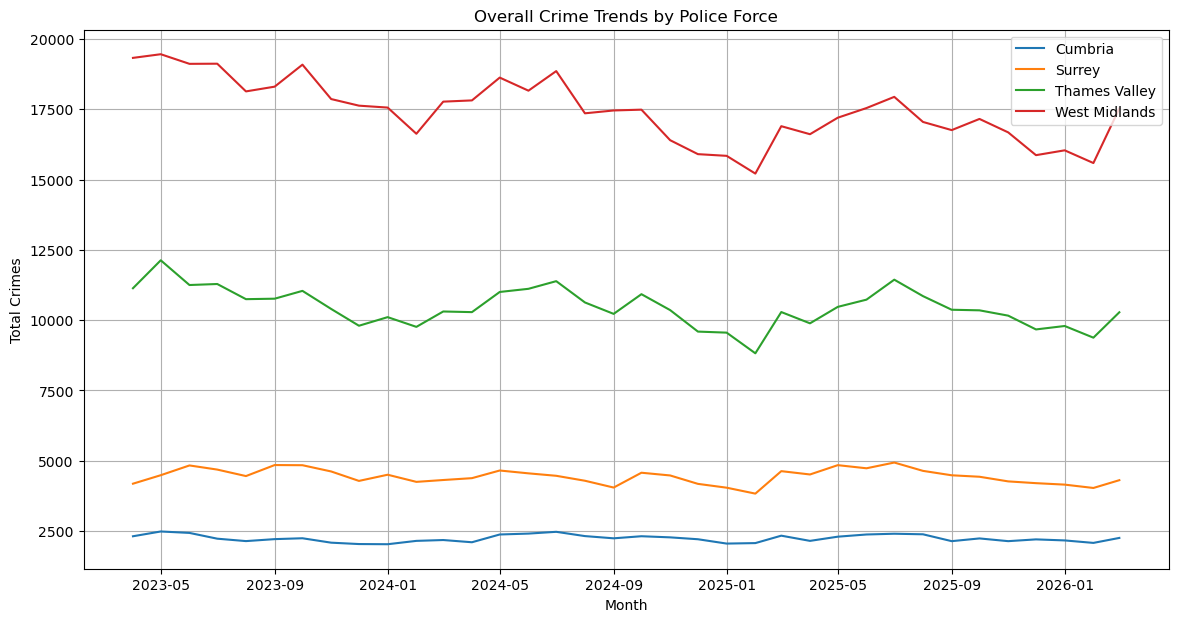

In [20]:
plt.figure(figsize=(14,7))

for force in crime_trend["force_name"].unique():

    subset = crime_trend[
        crime_trend["force_name"] == force
    ]

    plt.plot(
        subset["month_date"],
        subset["crime_count"],
        label=force)

plt.title("Overall Crime Trends by Police Force")
plt.xlabel("Month")
plt.ylabel("Total Crimes")
plt.legend()
plt.grid(True)
plt.savefig("crime_trends.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 2:
# What crime types drive crime volume, and how does the mix change over time?

In [13]:
crime_types = (
    crime
    .groupby("crime_type")["crime_count"]
    .sum()
    .reset_index()
    .sort_values("crime_count", ascending=False))

crime_types.head(10)

,crime_type,crime_count
13,Violence And Sexual Offences,470982
3,Criminal Damage And Arson,130047
12,Vehicle Crime,125979
8,Public Order,113106
6,Other Theft,110575
2,Burglary,76098
10,Shoplifting,54054
4,Drugs,45725
5,Other Crime,35927
9,Robbery,25678


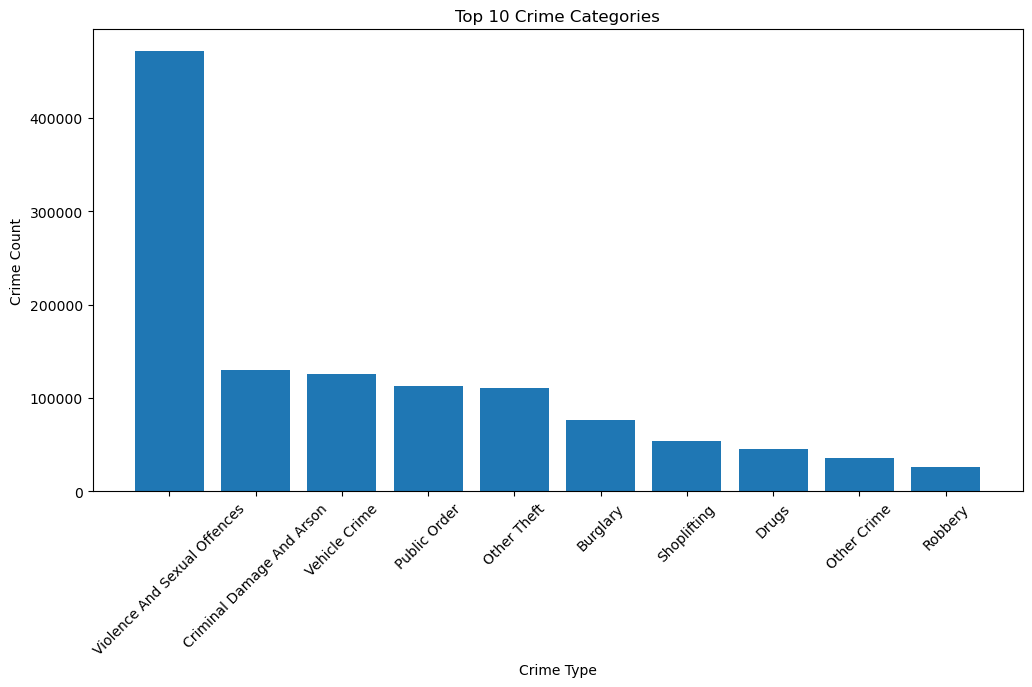

In [21]:
top_crimes = crime_types.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_crimes["crime_type"],
    top_crimes["crime_count"])

plt.xticks(rotation=45)
plt.title("Top 10 Crime Categories")
plt.xlabel("Crime Type")
plt.ylabel("Crime Count")
plt.savefig("top_crime_categories.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
top_categories = (
    crime
    .groupby("crime_type")["crime_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index)

crime_mix = (
    crime[
        crime["crime_type"].isin(top_categories)
    ]
    .groupby(["month_date", "crime_type"])["crime_count"]
    .sum()
    .reset_index()
)

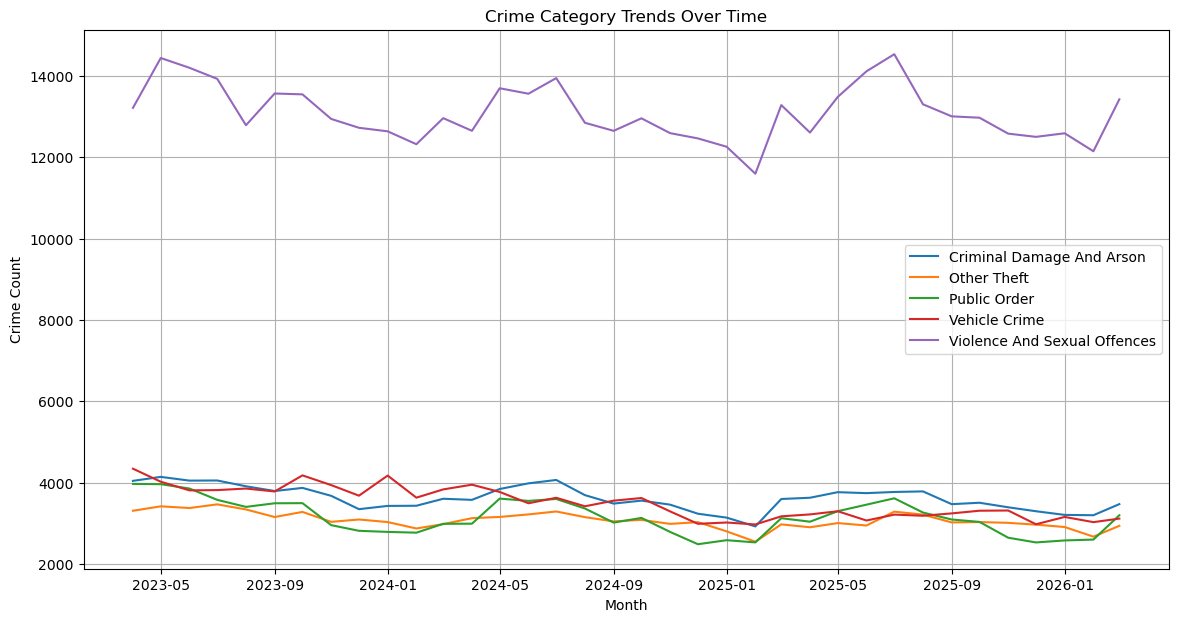

In [22]:
plt.figure(figsize=(14,7))

for category in crime_mix["crime_type"].unique():

    subset = crime_mix[
        crime_mix["crime_type"] == category
    ]

    plt.plot(
        subset["month_date"],
        subset["crime_count"],
        label=category
    )

plt.title("Crime Category Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.legend()
plt.grid(True)
plt.savefig("crime_mix_trends.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 3:
# Are there seasonal patterns or anomalous spikes at force or category level?

In [17]:
seasonality = (
    crime
    .groupby(["month_num", "force_name"])["crime_count"]
    .sum()
    .reset_index()
)

seasonality.head()

,month_num,force_name,crime_count
0,1,Cumbria,6260
1,1,Surrey,12702
2,1,Thames Valley,29458
3,1,West Midlands,49441
4,2,Cumbria,6308


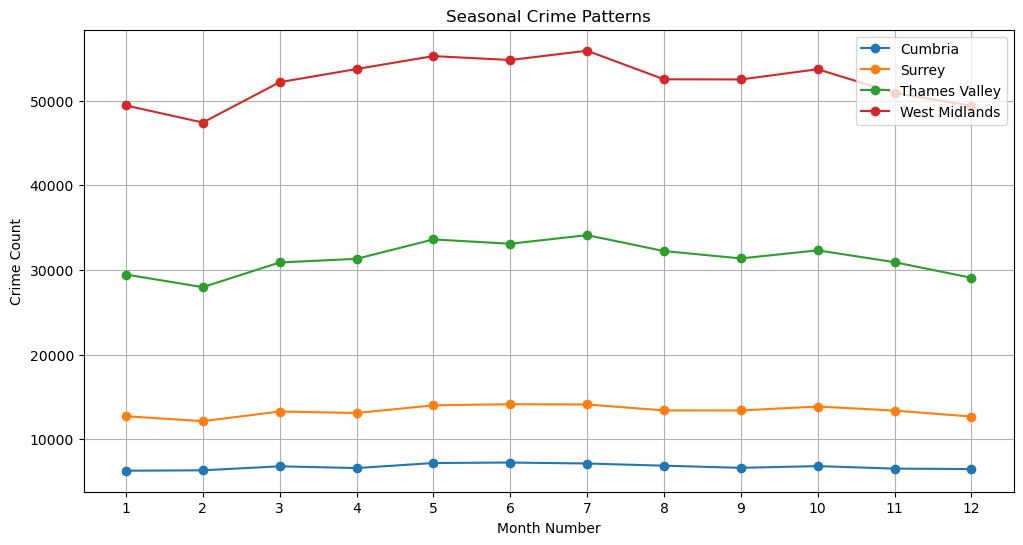

In [23]:
plt.figure(figsize=(12,6))

for force in seasonality["force_name"].unique():

    subset = seasonality[
        seasonality["force_name"] == force
    ]

    plt.plot(
        subset["month_num"],
        subset["crime_count"],
        marker="o",
        label=force
    )

plt.title("Seasonal Crime Patterns")
plt.xlabel("Month Number")
plt.ylabel("Crime Count")
plt.xticks(range(1,13))
plt.legend()
plt.grid(True)
plt.savefig("seasonal_crime_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
spikes = (
    crime
    .groupby(["month_date", "force_name"])["crime_count"]
    .sum()
    .reset_index())

threshold = (
    spikes["crime_count"].mean() +
    (2 * spikes["crime_count"].std()))

anomalies = spikes[
    spikes["crime_count"] > threshold]

anomalies

,month_date,force_name,crime_count


### Anomaly Interpretation

Using a threshold of mean crime count plus two standard deviations, no major anomalous monthly spikes were detected at police force level. This suggests that monthly crime volumes remain relatively stable within the expected range for each force.

However, West Midlands consistently records the highest crime volume, followed by Thames Valley, Surrey, and Cumbria. This reflects differences in population size, urbanisation, and force area characteristics rather than a single abnormal spike.

# Question 4
# How do selected police forces compare head-to-head on key metrics?



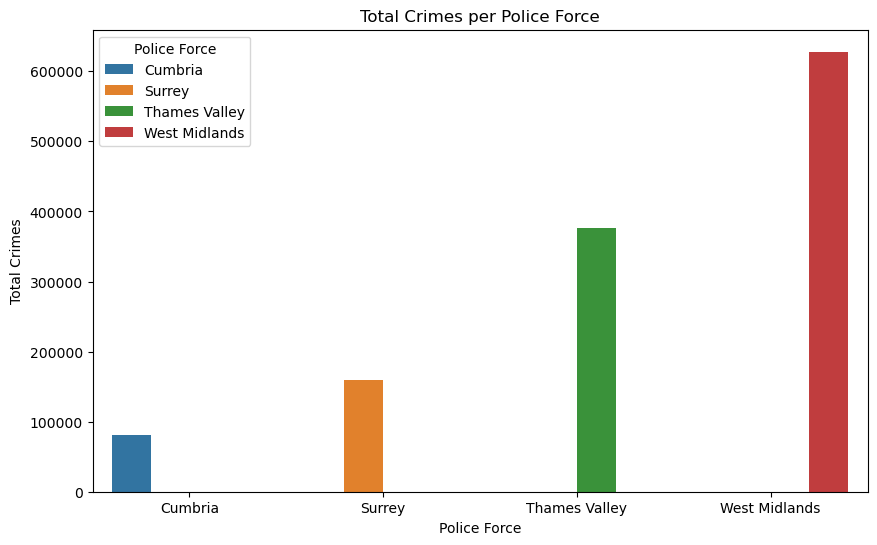

In [32]:
# Total crimes per police force
crimes_per_force = crime.groupby('force_name')['crime_count'].sum().reset_index()
crimes_per_force.columns = ['Police Force', 'Total Crimes']

plt.figure(figsize=(10, 6))
sns.barplot(x='Police Force', y='Total Crimes', data=crimes_per_force, hue='Police Force')
plt.title('Total Crimes per Police Force')
plt.ylabel('Total Crimes')
plt.show()

# Question 5
# How do forces compare on normalised crime rates per 10,000 population?


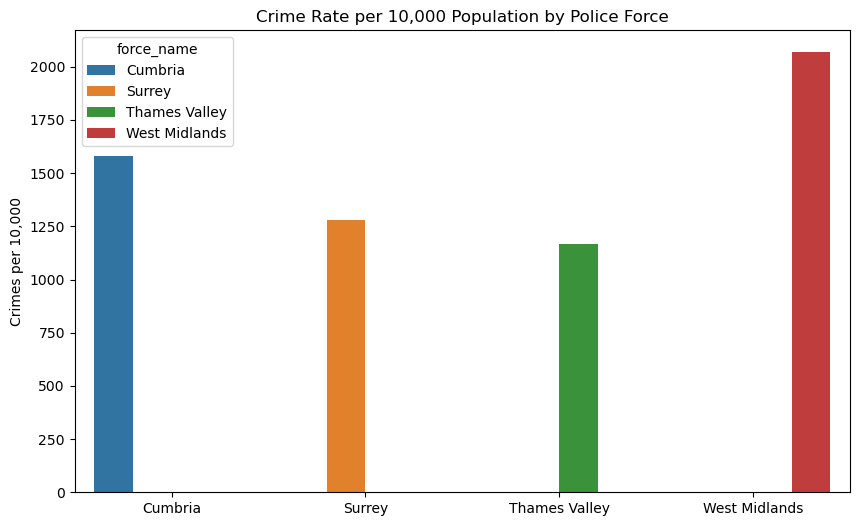

In [34]:
crimes_per_force = crime.groupby('force_name').agg(
    total_crimes=('crime_count', 'sum')
).reset_index()

# Get unique population per district then sum per force
pop_per_district = crime.groupby(['force_name', 'district_name'])['population_2024'].first().reset_index()
pop_per_force = pop_per_district.groupby('force_name')['population_2024'].sum().reset_index()
pop_per_force.columns = ['force_name', 'population']

crimes_per_force = crimes_per_force.merge(pop_per_force, on='force_name')
crimes_per_force['crime_rate_per_10000'] = (crimes_per_force['total_crimes'] / crimes_per_force['population']) * 10000

plt.figure(figsize=(10, 6))
sns.barplot(x='force_name', y='crime_rate_per_10000', data=crimes_per_force, hue='force_name')
plt.title('Crime Rate per 10,000 Population by Police Force')
plt.xlabel('')
plt.ylabel('Crimes per 10,000')
plt.show()

# Question 6
# How does crime relate to population and socioeconomic context?

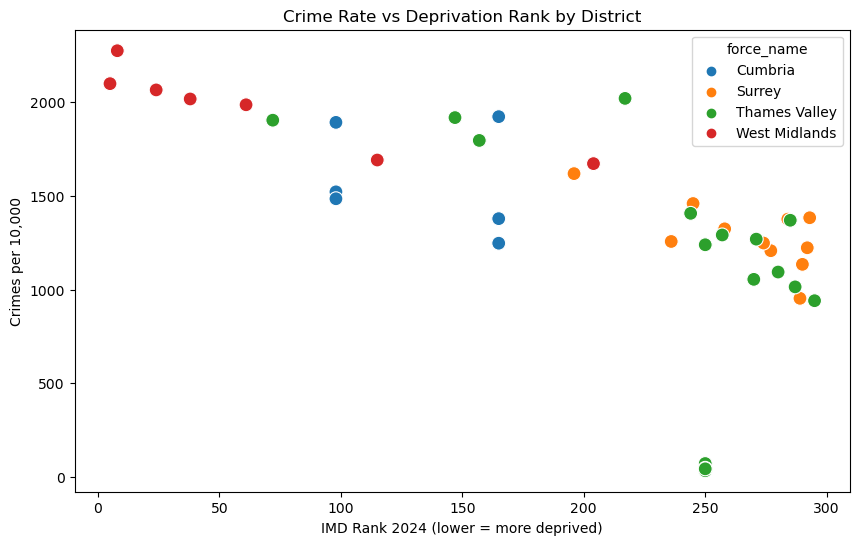

In [35]:
# Crime rate per district
crimes_per_district = crime.groupby(['force_name', 'district_name']).agg(
    total_crimes=('crime_count', 'sum'),
    population=('population_2024', 'first'),
    imd_rank=('imd_rank_2024', 'first'),
    house_price=('median_house_price_2024', 'first')
).reset_index()

crimes_per_district['crime_rate_per_10000'] = (crimes_per_district['total_crimes'] / crimes_per_district['population']) * 10000

plt.figure(figsize=(10, 6))
sns.scatterplot(x='imd_rank', y='crime_rate_per_10000', data=crimes_per_district, hue='force_name', s=100)
plt.title('Crime Rate vs Deprivation Rank by District')
plt.xlabel('IMD Rank 2024 (lower = more deprived)')
plt.ylabel('Crimes per 10,000')
plt.show()

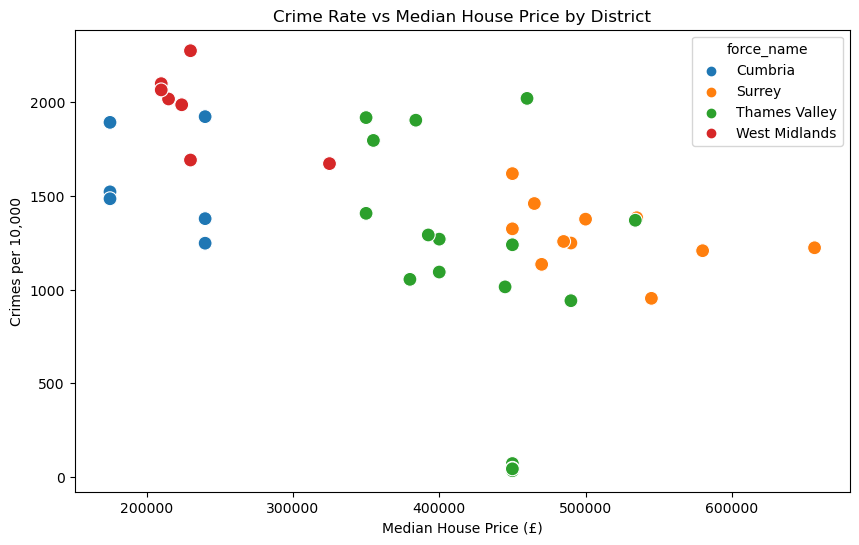

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='house_price', y='crime_rate_per_10000', data=crimes_per_district, hue='force_name', s=100)
plt.title('Crime Rate vs Median House Price by District')
plt.xlabel('Median House Price (£)')
plt.ylabel('Crimes per 10,000')
plt.show()

# Question 7. 
# Do any areas show repeat seasonal patterns?

In [42]:
# Average % crime change per district × month across all years

monthly_yr = (
    crime
    .groupby(
        ["district_name", "year", "month_num"]
    )["crime_count"]
    .sum()
    .reset_index()
    .sort_values(
        ["district_name", "year", "month_num"]
    )
)

monthly_yr["crime_pct_change"] = (
    monthly_yr
    .groupby(
        ["district_name", "year"]
    )["crime_count"]
    .pct_change()
    .fillna(0)
    .mul(100)
    .round(1)
)

monthly_yr.head()

,district_name,year,month_num,crime_count,crime_pct_change
0,Allerdale,2023,4,480,0.0
1,Allerdale,2023,5,476,-0.8
2,Allerdale,2023,6,478,0.4
3,Allerdale,2023,7,468,-2.1
4,Allerdale,2023,8,398,-15.0


In [43]:
#Average Percentage Change by Month
avg_pct = (
    monthly_yr
    .groupby(
        ["district_name", "month_num"]
    )["crime_pct_change"]
    .mean()
    .reset_index()
)

avg_pct.head()

,district_name,month_num,crime_pct_change
0,Allerdale,1,0.000000
1,Allerdale,2,1.900000
2,Allerdale,3,2.400000
3,Allerdale,4,-0.566667
4,Allerdale,5,6.433333


In [44]:
### Identify Most Volatile Districts
top5 = (
    avg_pct
    .groupby("district_name")["crime_pct_change"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

top5

['Buckinghamshire', 'Eden', 'Runnymede', 'Vale of White Horse', 'Reading']

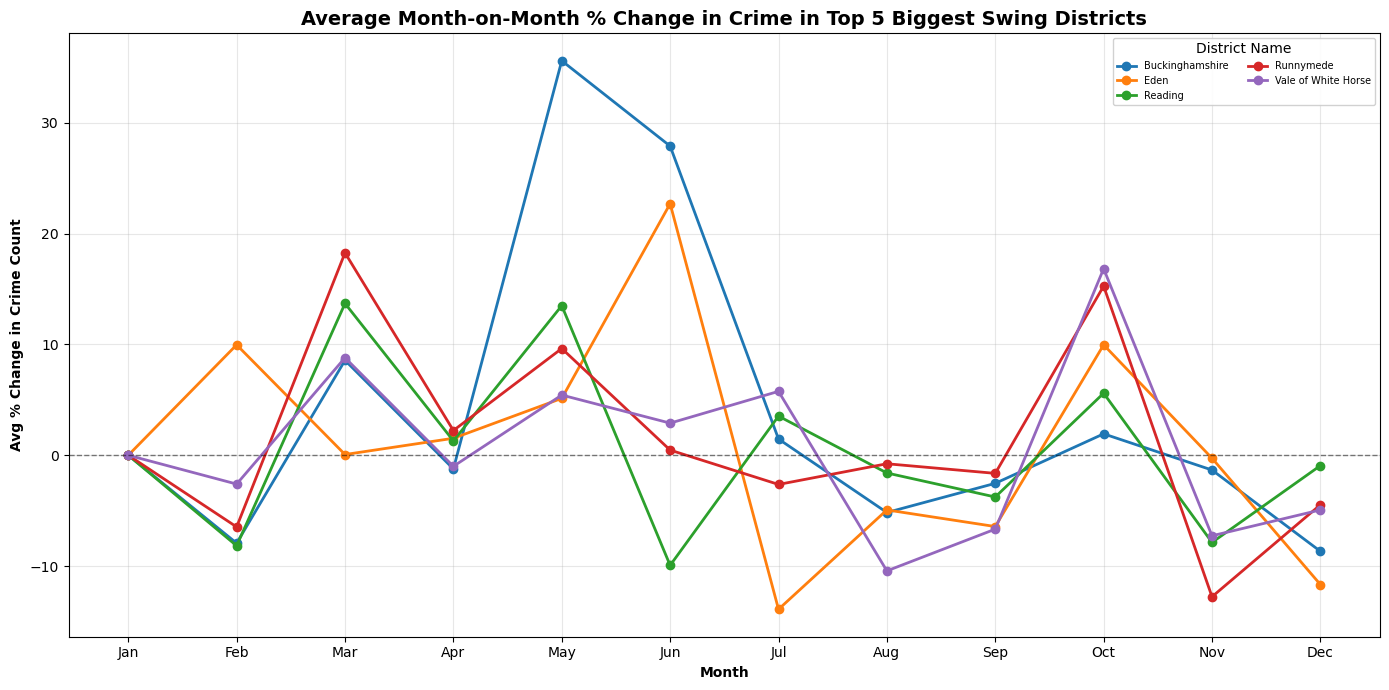

In [51]:
fig, ax = plt.subplots(figsize=(14, 7))
for district in sorted(top5):
    data = avg_pct[avg_pct["district_name"] == district]
    ax.plot(data["month_num"], data["crime_pct_change"],
            marker="o", linewidth=2, label=district)

ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

ax.set_title("Average Month-on-Month % Change in Crime in Top 5 Biggest Swing Districts",
             fontsize=14, fontweight="bold")

ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Avg % Change in Crime Count", fontweight="bold")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])

ax.legend(
    title="District Name",
    loc="upper right",
    ncol=2,
    fontsize=7,
    frameon=True,
    framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Question 8 
# Are there geographic clusters (hotspots) of specific crime categories, and how do these clusters differ by police force? (optional)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import contextily as ctx
import numpy as np

# ── Aggregate by force, crime type, and location ───────────────────────────
hotspots = (
    df.groupby(["force_name", "crime_type", "latitude", "longitude"])["crime_count"]
      .sum()
      .reset_index()
)

# ── GeoDataFrame ───────────────────────────────────────────────────────────
gdf = gpd.GeoDataFrame(
    hotspots,
    geometry=gpd.points_from_xy(hotspots["longitude"], hotspots["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# ── Colour map ─────────────────────────────────────────────────────────────
crime_types = sorted(gdf["crime_type"].unique())
colour_map  = {
    ct: mcolors.to_hex(plt.cm.tab20.colors[i % 20])
    for i, ct in enumerate(crime_types)
}

# ── One subplot per force ──────────────────────────────────────────────────
forces    = sorted(gdf["force_name"].unique())
max_count = gdf["crime_count"].max()
PAD       = 15000
JITTER    = 3000

# ── Round legend values to nearest 500 ────────────────────────────────────
def round_to_nice(val, base=500):
    return int(round(val / base) * base)

legend_counts = [
    round_to_nice(max_count * 0.25),
    round_to_nice(max_count * 0.5),
    round_to_nice(max_count)
]

ncols = 2
nrows = (len(forces) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10 * nrows))
axes = axes.flatten()

np.random.seed(42)

for i, force in enumerate(forces):
    ax     = axes[i]
    subset = gdf[gdf["force_name"] == force].copy()

    # ── Zoom to force extent ───────────────────────────────────────────────
    minx, miny, maxx, maxy = subset.total_bounds
    ax.set_xlim(minx - PAD, maxx + PAD)
    ax.set_ylim(miny - PAD, maxy + PAD)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=1)

    # ── Bubbles with jitter ────────────────────────────────────────────────
    for crime_type in crime_types:
        ct_subset = subset[subset["crime_type"] == crime_type].copy()
        if ct_subset.empty:
            continue

        bubble_sizes = (ct_subset["crime_count"] / max_count * 3000).clip(lower=40)

        x_jitter = ct_subset.geometry.x + np.random.uniform(-JITTER, JITTER, len(ct_subset))
        y_jitter = ct_subset.geometry.y + np.random.uniform(-JITTER, JITTER, len(ct_subset))

        ax.scatter(
            x_jitter,
            y_jitter,
            s=bubble_sizes,
            color=colour_map[crime_type],
            alpha=1.0,
            edgecolors="none",
            zorder=2
        )

    # ── Subtitle ───────────────────────────────────────────────────────────
    total_crimes = int(subset["crime_count"].sum())
    top_crime    = subset.groupby("crime_type")["crime_count"].sum().idxmax()
    ax.set_title(
        f"{force}\nTotal crimes: {total_crimes:,}  |  Most common: {top_crime}",
        fontsize=12, fontweight="bold", pad=10, color="black"
    )
    ax.set_axis_off()

    # ── Bubble size legend — upper right, small markers ────────────────────
    bubble_legend_handles = [
        plt.scatter([], [],
                    s=30,                          # fixed small display size
                    color="grey",
                    alpha=0.8,
                    label=f"{count:,}")
        for count in legend_counts
    ]
    bubble_legend = ax.legend(
        handles=bubble_legend_handles,
        title="Crime Count",
        loc="upper right",
        fontsize=7,
        framealpha=0.9,
        labelcolor="black",
        title_fontsize=7,
        facecolor="white",
        markerscale=1,
        handletextpad=0.5,
        borderpad=0.6
    )
    ax.add_artist(bubble_legend)

# ── Hide unused panels ─────────────────────────────────────────────────────
for j in range(len(forces), len(axes)):
    axes[j].set_visible(False)

# ── Shared crime type legend ───────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=colour_map[ct], label=ct)
    for ct in crime_types
]
fig.legend(
    handles=legend_handles,
    title="Crime Type",
    loc="lower center",
    ncol=5,
    fontsize=9,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

plt.suptitle(
    "Geographic Crime Clusters by Police Force\nBubble size = crime count  |  Colour = crime type",
    fontsize=16, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()